# First Property Prediction Baseline: Train a GNN to predict properties from Structure

This notebook trains a **TensorNet** graph neural network to predict the total material property (`e_total`) from crystal structure alone.

**What you will learn:**
1. How to load the dataset and prepare it for MatGL
2. How to configure and instantiate the model
3. How to train with PyTorch Lightning
4. How to evaluate: predicted vs actual, error distribution
5. What the results tell us about model capacity and data quality

**Note:** This uses a small test dataset (`data/test_materials.json`) to run quickly. Once you re-run `scripts/fetch_data.py` with your API key, point `JSON_PATH` at `mp_materials.json` for the full dataset.

In [1]:
from __future__ import annotations

import warnings
warnings.simplefilter("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import lightning as L
from pathlib import Path
from sklearn.model_selection import train_test_split

from matgl.graph._data_pyg import MGLDataLoader, collate_fn_graph
from lightning.pytorch.loggers import CSVLogger

from matprop_nn.datasets import MPDataset
from matprop_nn.models import build_regressor, get_engine
from matprop_nn.tasks import RegressionModule

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

SEED = 42
L.seed_everything(SEED)

Seed set to 42


42

## 1. Configuration

All hyperparameters in one place — nothing hard-coded below:

In [2]:
# ─── Data ───
JSON_PATH = Path("../data/test_materials.json")  # change to ../mp_materials.json for full data
TARGET_KEY = "e_total"
CACHE_DIR = "graph_cache_nb03"

# ─── Model ───
CUTOFF = 5.0       # graph edge cutoff (Å)
UNITS = 64         # hidden dimension
NBLOCKS = 3        # interaction layers
NUM_RBF = 32       # radial basis functions

# ─── Training ───
MAX_EPOCHS = 50    # increase for full dataset (e.g. 200)
BATCH_SIZE = 8
LR = 1e-3
TEST_FRAC = 0.15
VAL_FRAC = 0.15
ACCELERATOR = "cpu"  # change to "gpu" if available

## 2. Load dataset and compute target statistics

In [3]:
ds = MPDataset(
    json_path=JSON_PATH,
    target_key=TARGET_KEY,
    cutoff=CUTOFF,
    cache_dir=CACHE_DIR,
)

targets = np.array(ds.targets)
data_mean = float(targets.mean())
data_std = float(targets.std())

print(f"Dataset size : {len(ds)}")
print(f"Elements     : {ds.element_types}")
print(f"Target stats : mean={data_mean:.2f}, std={data_std:.2f}")
print(f"Target range : [{targets.min():.2f}, {targets.max():.2f}]")

Processing...



  0%|          | 0/20 [00:00<?, ?it/s]


100%|██████████| 20/20 [00:00<00:00, 2777.87it/s]

Dataset size : 20
Elements     : ('O', 'Na', 'Si', 'Cl', 'Ti', 'Ge', 'Sr', 'Cs')
Target stats : mean=68.19, std=116.04
Target range : [5.63, 300.70]



Done!


## 3. Train / validation / test split

In [4]:
indices = list(range(len(ds)))
train_val_idx, test_idx = train_test_split(indices, test_size=TEST_FRAC, random_state=SEED)
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=VAL_FRAC / (1 - TEST_FRAC),
    random_state=SEED,
)

train_data = torch.utils.data.Subset(ds.mgl_dataset, train_idx)
val_data = torch.utils.data.Subset(ds.mgl_dataset, val_idx)
test_data = torch.utils.data.Subset(ds.mgl_dataset, test_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

train_loader, val_loader, test_loader = MGLDataLoader(
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    collate_fn=collate_fn_graph,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

Train: 14 | Val: 3 | Test: 3


## 4. Build model and Lightning module

In [5]:
model = build_regressor(
    element_types=ds.element_types,
    cutoff=CUTOFF,
    units=UNITS,
    nblocks=NBLOCKS,
    num_rbf=NUM_RBF,
    is_intensive=True,
    ntargets=1,
)

engine = get_engine("tensornet")

lit_module = RegressionModule(
    model,
    engine,
    data_mean=data_mean,
    data_std=data_std,
    lr=LR,
)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: TensorNet")
print(f"  Parameters : {total_params:,} total, {trainable:,} trainable")
print(f"  Elements   : {len(ds.element_types)}")
print(f"  Blocks     : {NBLOCKS}")
print(f"  Hidden dim : {UNITS}")

Model: TensorNet
  Parameters : 269,474 total, 269,442 trainable
  Elements   : 8
  Blocks     : 3
  Hidden dim : 64


## 5. Train

In [6]:
logger = CSVLogger("logs_nb03", name="property_baseline")

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator=ACCELERATOR,
    logger=logger,
    enable_progress_bar=True,
    log_every_n_steps=1,
)

trainer.fit(lit_module, train_dataloaders=train_loader, val_dataloaders=val_loader)

GPU available: True (cuda), used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ TensorNet         │  269 K │ train │     0 │
│ 1 │ mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 2 │ rmse  │ MeanSquaredError  │      0 │ train │     0 │
└───┴───────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 269 K                                                                                            
Non-trainable params: 32                                                                                           
Total params: 269 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 72                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=50` reached.


## 6. Training curves

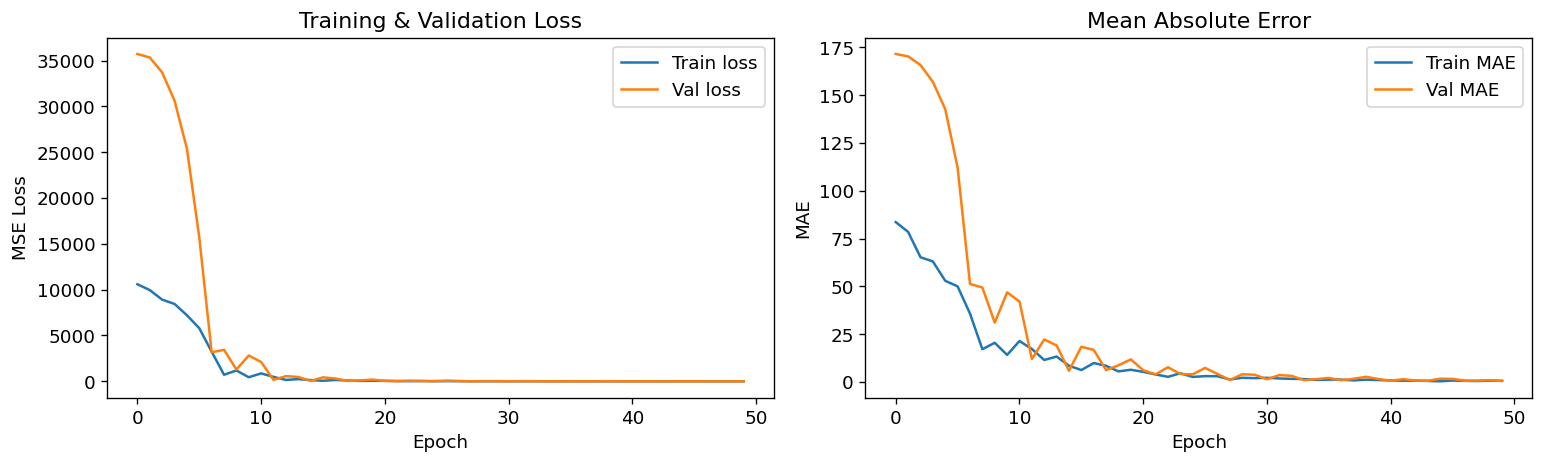

In [7]:
metrics_path = Path(logger.log_dir) / "metrics.csv"
metrics = pd.read_csv(metrics_path)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) Loss
ax = axes[0]
train_loss = metrics[["epoch", "train_Total_Loss"]].dropna()
val_loss = metrics[["epoch", "val_Total_Loss"]].dropna()
ax.plot(train_loss["epoch"], train_loss["train_Total_Loss"], label="Train loss")
ax.plot(val_loss["epoch"], val_loss["val_Total_Loss"], label="Val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training & Validation Loss")
ax.legend()

# (b) MAE
ax2 = axes[1]
train_mae = metrics[["epoch", "train_MAE"]].dropna()
val_mae = metrics[["epoch", "val_MAE"]].dropna()
ax2.plot(train_mae["epoch"], train_mae["train_MAE"], label="Train MAE")
ax2.plot(val_mae["epoch"], val_mae["val_MAE"], label="Val MAE")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MAE")
ax2.set_title("Mean Absolute Error")
ax2.legend()

plt.tight_layout()
plt.show()

## 7. Evaluate on the test set

In [8]:
test_results = trainer.test(lit_module, dataloaders=test_loader)
print(f"\nTest MAE : {test_results[0]['test_MAE']:.2f}")
print(f"Test RMSE: {test_results[0]['test_RMSE']:.2f}")

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_MAE          │    0.5742643475532532     │
│         test_RMSE         │    0.6095474362373352     │
│      test_Total_Loss      │    0.3715480864048004     │
└───────────────────────────┴───────────────────────────┘


Test MAE : 0.57
Test RMSE: 0.61


## 8. Predicted vs Actual plot

The most important diagnostic — does the model capture the trend?

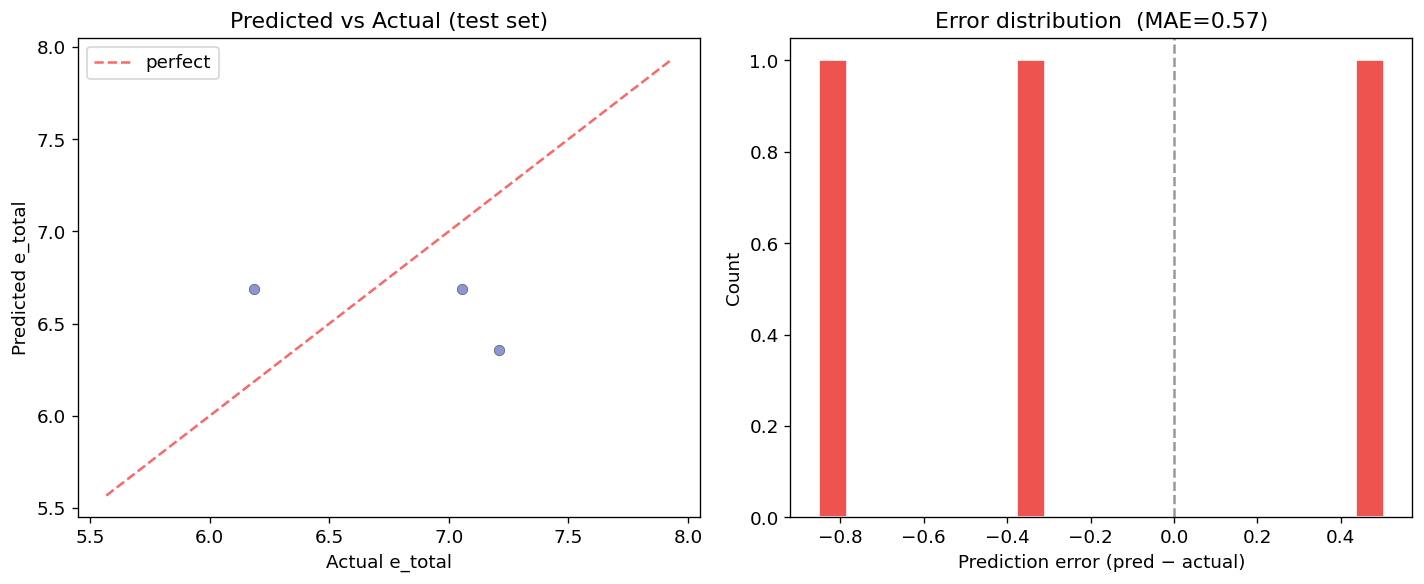

In [9]:
from matprop_nn.models._tensornet import _batch_num_edges, _batch_num_nodes

lit_module.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        g, lat, state_attr, labels = batch
        preds = lit_module(g=g, lat=lat, state_attr=state_attr)
        scaled_preds = preds * lit_module.data_std + lit_module.data_mean
        all_preds.append(scaled_preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds).flatten()
all_labels = np.concatenate(all_labels).flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Predicted vs Actual
ax = axes[0]
ax.scatter(all_labels, all_preds, s=40, alpha=0.7, edgecolors="k", linewidths=0.3, c="#5C6BC0")
lim_lo = min(all_labels.min(), all_preds.min()) * 0.9
lim_hi = max(all_labels.max(), all_preds.max()) * 1.1
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "r--", alpha=0.6, label="perfect")
ax.set_xlabel("Actual e_total")
ax.set_ylabel("Predicted e_total")
ax.set_title("Predicted vs Actual (test set)")
ax.legend()

# (b) Error distribution
errors = all_preds - all_labels
ax2 = axes[1]
ax2.hist(errors, bins=20, edgecolor="white", color="#EF5350")
ax2.axvline(0, color="k", linestyle="--", alpha=0.4)
ax2.set_xlabel("Prediction error (pred − actual)")
ax2.set_ylabel("Count")
ax2.set_title(f"Error distribution  (MAE={np.abs(errors).mean():.2f})")

plt.tight_layout()
plt.show()

## 9. Per-material breakdown

In [10]:
test_mpids = [ds.material_ids[i] for i in test_idx]

results_df = pd.DataFrame({
    "material_id": test_mpids[:len(all_labels)],
    "actual": all_labels,
    "predicted": all_preds,
    "error": errors,
    "abs_error": np.abs(errors),
})

print("Test set predictions:")
display(results_df.sort_values("abs_error", ascending=False).reset_index(drop=True))

Test set predictions:


,material_id,actual,predicted,error,abs_error
0,mp-test-NaCl-17,7.211081,6.358864,-0.852217,0.852217
1,mp-test-CsCl-15,6.185338,6.689251,0.503913,0.503913
2,mp-test-CsCl-0,7.055910,6.689247,-0.366663,0.366663


## 10. Clean up and next steps

In [11]:
import shutil

for d in ["logs_nb03", CACHE_DIR]:
    shutil.rmtree(d, ignore_errors=True)

print("Cleaned up temporary files.")

Cleaned up temporary files.


## What to try next

| Improvement | How |
|---|---|
| **Use the full dataset** | Re-run `scripts/fetch_data.py` with your API key, then set `JSON_PATH = "../mp_materials.json"` |
| **Log-transform the target** | Predict `log₁₀(e_total)` instead — handles the extreme skew (see notebook 01) |
| **Train longer** | Set `MAX_EPOCHS = 200+` with GPU (`ACCELERATOR = "gpu"`) |
| **Tune hyperparameters** | Try `NBLOCKS ∈ {2,3,4}`, `UNITS ∈ {32,64,128}`, `CUTOFF ∈ {4,5,6}` |
| **Transfer learning** | Load a pre-trained MatGL potential and fine-tune for property prediction |
| **Predict the tensor** | Set `ntargets=6` (Voigt notation) to predict the full dielectric tensor |

**For CLI training** (more convenient for long runs):
```bash
python scripts/train.py configs/default.yaml
```